# Backtesting & Validation: RL vs Traditional Strategies
## Big Data Analytics (EECS-6893) - Final Project
### Comprehensive Performance Comparison & Stress Testing

**Team:** Sejal Mittal (sm5756) & Neha Arun Angadi (naa2204)

This notebook compares:
1. **RL Agent (Trained PPO)** - Dynamic ESG-aware portfolio
2. **Equal Weight** - Baseline (1/N allocation)
3. **Max Sharpe (Traditional)** - Mean-variance optimization
4. **ESG Constrained (≥60)** - MVO with ESG constraint

**Evaluation Criteria:**
- Cumulative returns
- Sharpe ratio
- Maximum drawdown
- ESG score maintenance
- Volatility
- Stress test performance (volatile periods)

---
## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported")

✅ Libraries imported


In [2]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/ESG_Portfolio_Data/'

# Load all required data
print("Loading data...")
combined_df = pd.read_csv(f'{data_path}combined_features.csv')
price_df = pd.read_csv(f'{data_path}stock_prices_cleaned.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])

# Load portfolio weights from all strategies
optimal_portfolios = pd.read_csv(f'{data_path}optimal_portfolios.csv')
rl_portfolio = pd.read_csv(f'{data_path}rl_trained_portfolio.csv')

print("✅ Data loaded successfully")
print(f"   Price data: {price_df.shape}")
print(f"   Date range: {price_df['Date'].min()} to {price_df['Date'].max()}")

Mounted at /content/drive
Loading data...
✅ Data loaded successfully
   Price data: (30080, 9)
   Date range: 2022-11-16 00:00:00 to 2025-11-14 00:00:00


---
## 2. Prepare Returns Data & Portfolio Weights

In [3]:
# Create returns matrix
price_pivot = price_df.pivot(index='Date', columns='Ticker', values='Close')
returns_matrix = price_pivot.pct_change().dropna()

# Extract tickers and ESG scores
tickers = combined_df['Ticker'].values
esg_scores = combined_df['Total_ESG_Score'].values

print(f"Returns matrix: {returns_matrix.shape}")
print(f"Trading days: {len(returns_matrix)}")

# Prepare portfolio weights for all strategies
portfolios = {
    'Equal Weight': optimal_portfolios['Equal_Weight'].values,
    'Max Sharpe': optimal_portfolios['Max_Sharpe_Traditional'].values,
    'ESG Constrained (≥60)': optimal_portfolios['ESG_Constrained_60'].values,
    'RL Agent (Trained)': rl_portfolio.set_index('Ticker').loc[tickers, 'RL_Trained_Weights'].values
}

print("\n✅ Portfolio weights prepared for all strategies")
for name, weights in portfolios.items():
    esg_score = np.dot(weights, esg_scores)
    print(f"   {name}: ESG Score = {esg_score:.2f}, Sum of weights = {weights.sum():.4f}")

Returns matrix: (751, 40)
Trading days: 751

✅ Portfolio weights prepared for all strategies
   Equal Weight: ESG Score = 49.84, Sum of weights = 1.0000
   Max Sharpe: ESG Score = 50.41, Sum of weights = 1.0000
   ESG Constrained (≥60): ESG Score = 60.00, Sum of weights = 1.0000
   RL Agent (Trained): ESG Score = 52.25, Sum of weights = 1.0000


---
## 3. Define Backtesting Functions

In [4]:
def backtest_portfolio(weights, returns_data, initial_value=1000000, transaction_cost=0.001, rebalance_freq=None):
    """
    Backtest a portfolio with given weights.

    Parameters:
    - weights: portfolio weights (static or dynamic)
    - returns_data: DataFrame of daily returns
    - initial_value: starting portfolio value
    - transaction_cost: cost per trade (as fraction)
    - rebalance_freq: rebalancing frequency in days (None = no rebalancing)

    Returns:
    - portfolio_values: list of daily portfolio values
    - portfolio_returns: list of daily portfolio returns
    - total_costs: total transaction costs incurred
    """

    portfolio_value = initial_value
    portfolio_values = [initial_value]
    portfolio_returns = []
    current_weights = weights.copy()
    total_costs = 0
    days_since_rebalance = 0

    for i in range(len(returns_data)):
        # Get today's returns
        daily_returns = returns_data.iloc[i].values

        # Calculate portfolio return
        portfolio_return = np.dot(current_weights, daily_returns)

        # Update portfolio value
        portfolio_value = portfolio_value * (1 + portfolio_return)

        # Rebalancing logic
        days_since_rebalance += 1
        if rebalance_freq is not None and days_since_rebalance >= rebalance_freq:
            # Calculate turnover
            turnover = np.sum(np.abs(weights - current_weights))
            cost = turnover * transaction_cost * portfolio_value
            portfolio_value -= cost
            total_costs += cost

            # Reset to target weights
            current_weights = weights.copy()
            days_since_rebalance = 0
        else:
            # Drift weights naturally with returns
            current_weights = current_weights * (1 + daily_returns)
            current_weights = current_weights / np.sum(current_weights)

        portfolio_values.append(portfolio_value)
        portfolio_returns.append(portfolio_return)

    return portfolio_values, portfolio_returns, total_costs


def calculate_metrics(portfolio_values, portfolio_returns, risk_free_rate=0.04):
    """
    Calculate performance metrics for a portfolio.
    """
    portfolio_returns = np.array(portfolio_returns)

    # Total return
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0]

    # Annualized return
    n_days = len(portfolio_returns)
    annualized_return = (1 + total_return) ** (252 / n_days) - 1

    # Annualized volatility
    annualized_volatility = np.std(portfolio_returns) * np.sqrt(252)

    # Sharpe ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility if annualized_volatility > 0 else 0

    # Maximum drawdown
    cumulative = np.array(portfolio_values)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = np.min(drawdown)

    # Sortino ratio (downside deviation)
    downside_returns = portfolio_returns[portfolio_returns < 0]
    downside_deviation = np.std(downside_returns) * np.sqrt(252) if len(downside_returns) > 0 else 0
    sortino_ratio = (annualized_return - risk_free_rate) / downside_deviation if downside_deviation > 0 else 0

    # Win rate
    win_rate = np.sum(portfolio_returns > 0) / len(portfolio_returns) if len(portfolio_returns) > 0 else 0

    return {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate
    }

print("✅ Backtesting functions defined")

✅ Backtesting functions defined


---
## 4. Run Backtests on Full Dataset

In [5]:
print("🚀 Running backtests on full dataset...\n")

# Run backtests for all strategies
backtest_results = {}

for strategy_name, weights in portfolios.items():
    print(f"Backtesting: {strategy_name}...")

    # Rebalance quarterly (63 trading days) for static strategies
    # RL agent doesn't rebalance (dynamic weights from training)
    rebalance_freq = None if 'RL' in strategy_name else 63

    values, returns, costs = backtest_portfolio(
        weights=weights,
        returns_data=returns_matrix,
        initial_value=1000000,
        transaction_cost=0.001,
        rebalance_freq=rebalance_freq
    )

    metrics = calculate_metrics(values, returns)

    backtest_results[strategy_name] = {
        'values': values,
        'returns': returns,
        'costs': costs,
        'metrics': metrics,
        'esg_score': np.dot(weights, esg_scores)
    }

    print(f"   Final Value: ${values[-1]:,.2f}")
    print(f"   Total Return: {metrics['total_return']*100:.2f}%")
    print(f"   Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
    print(f"   Transaction Costs: ${costs:,.2f}\n")

print("✅ All backtests complete")

🚀 Running backtests on full dataset...

Backtesting: Equal Weight...
   Final Value: $1,406,617.37
   Total Return: 40.66%
   Sharpe Ratio: 0.535
   Transaction Costs: $1,183.52

Backtesting: Max Sharpe...
   Final Value: $1,140,280.75
   Total Return: 14.03%
   Sharpe Ratio: 0.036
   Transaction Costs: $698.00

Backtesting: ESG Constrained (≥60)...
   Final Value: $1,716,961.41
   Total Return: 71.70%
   Sharpe Ratio: 0.941
   Transaction Costs: $1,142.23

Backtesting: RL Agent (Trained)...
   Final Value: $1,910,549.28
   Total Return: 91.05%
   Sharpe Ratio: 1.179
   Transaction Costs: $0.00

✅ All backtests complete


---
## 5. Comprehensive Performance Comparison

In [6]:
print("="*90)
print("📊 COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*90)

# Create comparison DataFrame
comparison_data = []

for strategy_name, results in backtest_results.items():
    metrics = results['metrics']
    comparison_data.append({
        'Strategy': strategy_name,
        'Total Return (%)': metrics['total_return'] * 100,
        'Annualized Return (%)': metrics['annualized_return'] * 100,
        'Volatility (%)': metrics['annualized_volatility'] * 100,
        'Sharpe Ratio': metrics['sharpe_ratio'],
        'Sortino Ratio': metrics['sortino_ratio'],
        'Max Drawdown (%)': metrics['max_drawdown'] * 100,
        'Win Rate (%)': metrics['win_rate'] * 100,
        'ESG Score': results['esg_score'],
        'Transaction Costs ($)': results['costs']
    })

comparison_df = pd.DataFrame(comparison_data)

# Display results
print("\n" + comparison_df.to_string(index=False))

# Highlight best performers
print("\n" + "="*90)
print("🏆 BEST PERFORMERS:")
print("="*90)
print(f"Highest Return: {comparison_df.loc[comparison_df['Total Return (%)'].idxmax(), 'Strategy']}")
print(f"Best Sharpe: {comparison_df.loc[comparison_df['Sharpe Ratio'].idxmax(), 'Strategy']}")
print(f"Lowest Drawdown: {comparison_df.loc[comparison_df['Max Drawdown (%)'].idxmax(), 'Strategy']}")
print(f"Highest ESG: {comparison_df.loc[comparison_df['ESG Score'].idxmax(), 'Strategy']}")
print("="*90)

📊 COMPREHENSIVE PERFORMANCE COMPARISON

             Strategy  Total Return (%)  Annualized Return (%)  Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  ESG Score  Transaction Costs ($)
         Equal Weight         40.661737              12.129745       15.191729      0.535143       0.767220        -18.654442     52.729694  49.840000            1183.524438
           Max Sharpe         14.028075               4.503408       13.955345      0.036073       0.049428        -20.927861     52.463382  50.406196             697.997703
ESG Constrained (≥60)         71.696141              19.887666       16.875894      0.941441       1.272151        -20.434975     55.259654  60.000000            1142.229418
   RL Agent (Trained)         91.054928              24.263442       17.186265      1.179049       1.692837        -20.912942     55.659121  52.250065               0.000000

🏆 BEST PERFORMERS:
Highest Return: RL Agent (Trained)
Best Sharpe: RL Agent (Trained)
Low

---
## 6. Visualize Portfolio Performance Over Time

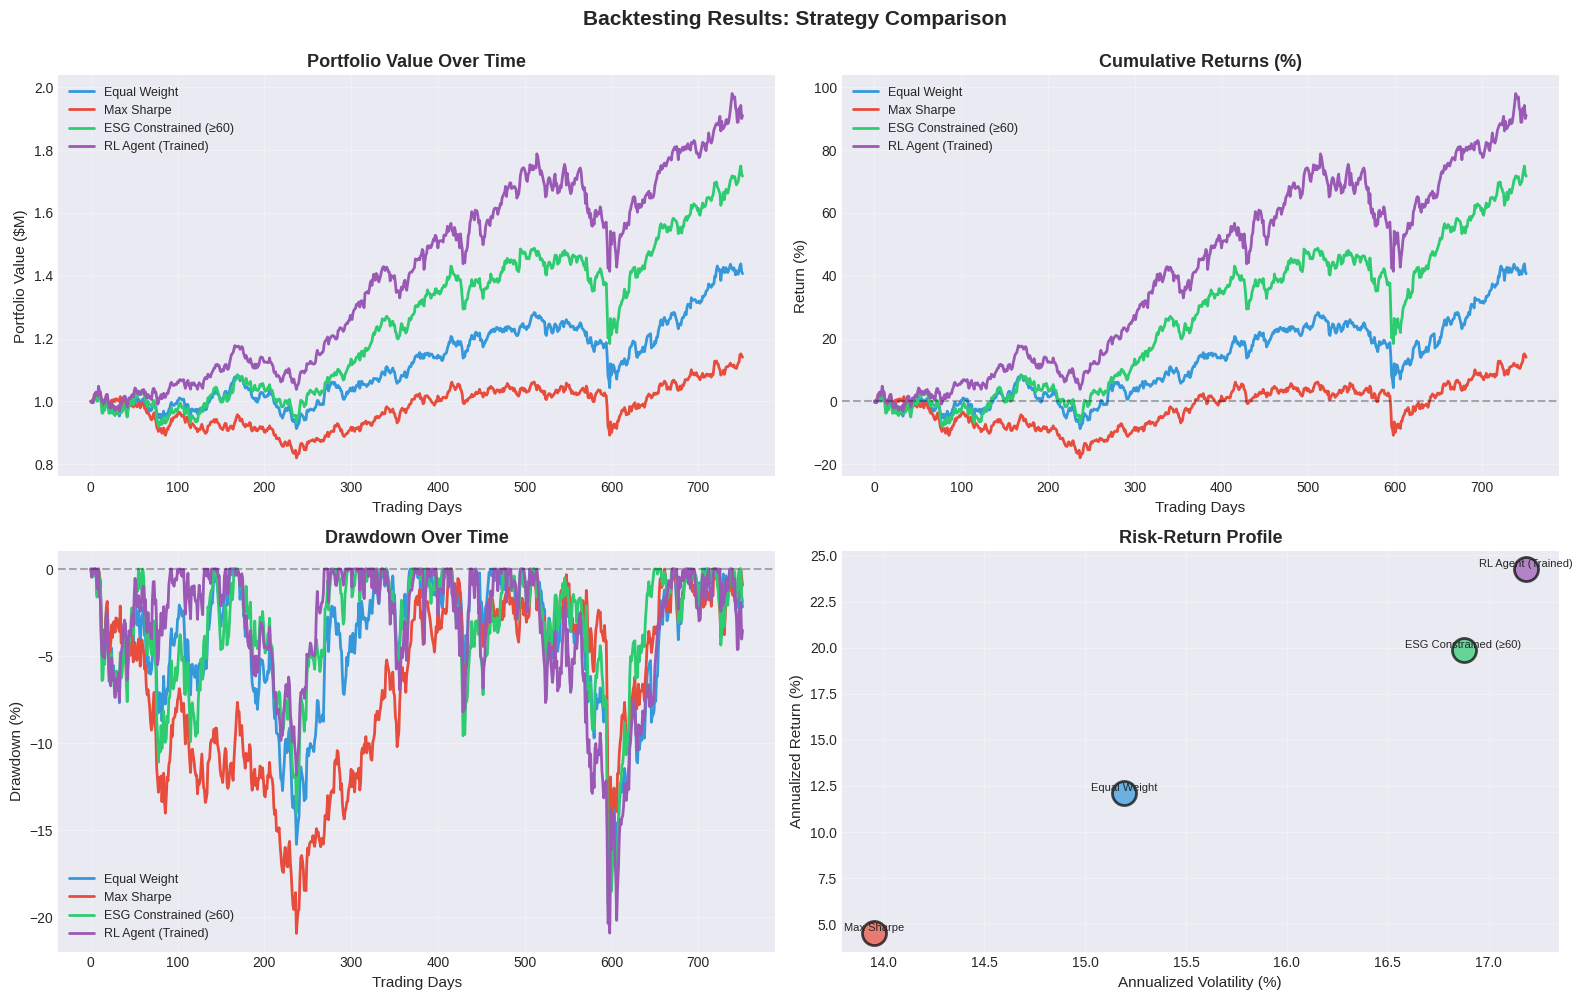

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Color scheme
colors = {
    'Equal Weight': '#3498db',
    'Max Sharpe': '#e74c3c',
    'ESG Constrained (≥60)': '#2ecc71',
    'RL Agent (Trained)': '#9b59b6'
}

# 1. Portfolio Values Over Time
ax1 = axes[0, 0]
for strategy_name, results in backtest_results.items():
    values = np.array(results['values']) / 1000000  # Convert to millions
    ax1.plot(values, label=strategy_name, linewidth=2, color=colors[strategy_name])

ax1.set_title('Portfolio Value Over Time', fontweight='bold', fontsize=13)
ax1.set_xlabel('Trading Days', fontsize=11)
ax1.set_ylabel('Portfolio Value ($M)', fontsize=11)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Cumulative Returns (%)
ax2 = axes[0, 1]
for strategy_name, results in backtest_results.items():
    values = results['values']
    cumulative_returns = [(v - values[0]) / values[0] * 100 for v in values]
    ax2.plot(cumulative_returns, label=strategy_name, linewidth=2, color=colors[strategy_name])

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('Cumulative Returns (%)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Trading Days', fontsize=11)
ax2.set_ylabel('Return (%)', fontsize=11)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Drawdown Analysis
ax3 = axes[1, 0]
for strategy_name, results in backtest_results.items():
    values = np.array(results['values'])
    running_max = np.maximum.accumulate(values)
    drawdown = (values - running_max) / running_max * 100
    ax3.plot(drawdown, label=strategy_name, linewidth=2, color=colors[strategy_name])

ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax3.set_title('Drawdown Over Time', fontweight='bold', fontsize=13)
ax3.set_xlabel('Trading Days', fontsize=11)
ax3.set_ylabel('Drawdown (%)', fontsize=11)
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Risk-Return Scatter
ax4 = axes[1, 1]
for strategy_name, results in backtest_results.items():
    metrics = results['metrics']
    ax4.scatter(
        metrics['annualized_volatility'] * 100,
        metrics['annualized_return'] * 100,
        s=300,
        alpha=0.7,
        color=colors[strategy_name],
        edgecolors='black',
        linewidth=2
    )
    ax4.annotate(
        strategy_name,
        (metrics['annualized_volatility'] * 100, metrics['annualized_return'] * 100),
        fontsize=8,
        ha='center',
        va='bottom'
    )

ax4.set_title('Risk-Return Profile', fontweight='bold', fontsize=13)
ax4.set_xlabel('Annualized Volatility (%)', fontsize=11)
ax4.set_ylabel('Annualized Return (%)', fontsize=11)
ax4.grid(True, alpha=0.3)

plt.suptitle('Backtesting Results: Strategy Comparison', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

---
## 7. Performance Metrics Visualization

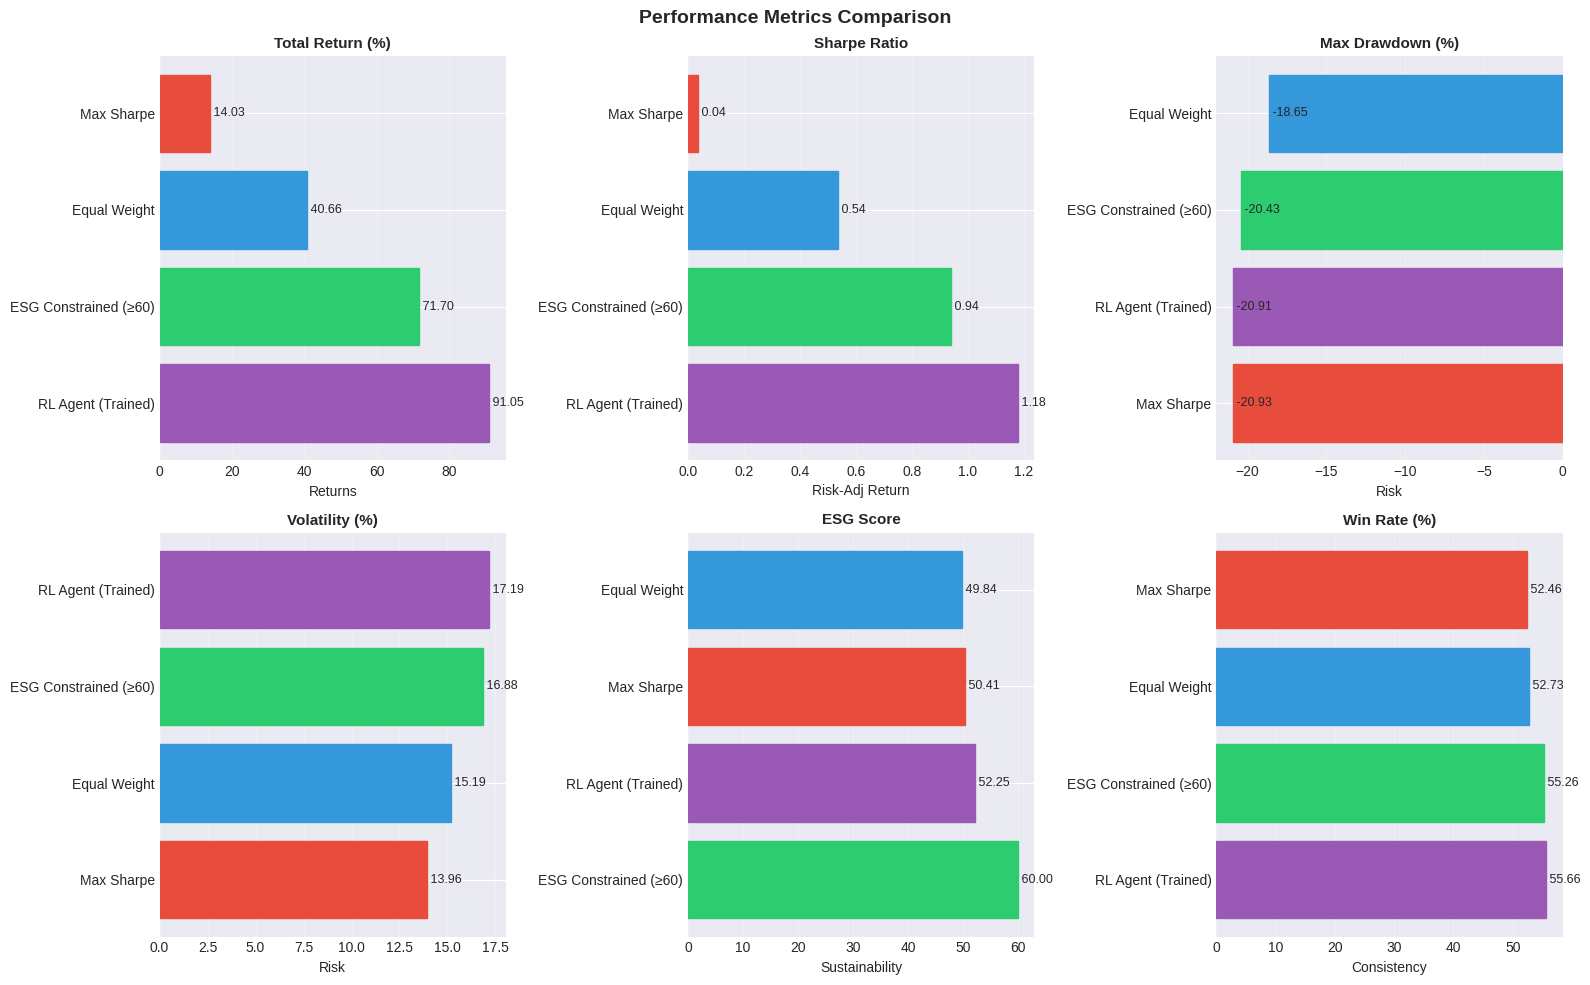

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('Total Return (%)', 'Returns'),
    ('Sharpe Ratio', 'Risk-Adj Return'),
    ('Max Drawdown (%)', 'Risk'),
    ('Volatility (%)', 'Risk'),
    ('ESG Score', 'Sustainability'),
    ('Win Rate (%)', 'Consistency')
]

for idx, (metric, category) in enumerate(metrics_to_plot):
    ax = axes[idx]

    data = comparison_df[['Strategy', metric]].sort_values(metric, ascending=(metric == 'Max Drawdown (%)' or metric == 'Volatility (%)'))

    bars = ax.barh(data['Strategy'], data[metric])

    # Color bars
    for i, bar in enumerate(bars):
        strategy = data.iloc[i]['Strategy']
        bar.set_color(colors[strategy])

    ax.set_title(f'{metric}', fontweight='bold', fontsize=11)
    ax.set_xlabel(category, fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, v in enumerate(data[metric]):
        ax.text(v, i, f' {v:.2f}', va='center', fontsize=9)

plt.suptitle('Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Out-of-Sample Test (Last 6 Months)

In [9]:
print("📊 Out-of-Sample Test: Last 6 Months\n")

# Use last 6 months (approximately 126 trading days)
test_period = 126
test_returns = returns_matrix.iloc[-test_period:]

print(f"Test period: {test_returns.index.min()} to {test_returns.index.max()}")
print(f"Trading days: {len(test_returns)}\n")

# Run backtests on test period
oos_results = {}

for strategy_name, weights in portfolios.items():
    rebalance_freq = None if 'RL' in strategy_name else 21  # Monthly rebalance

    values, returns, costs = backtest_portfolio(
        weights=weights,
        returns_data=test_returns,
        initial_value=1000000,
        transaction_cost=0.001,
        rebalance_freq=rebalance_freq
    )

    metrics = calculate_metrics(values, returns)
    oos_results[strategy_name] = metrics

# Display results
oos_comparison = pd.DataFrame([
    {
        'Strategy': name,
        'Return (%)': metrics['total_return'] * 100,
        'Sharpe': metrics['sharpe_ratio'],
        'Max DD (%)': metrics['max_drawdown'] * 100,
        'Volatility (%)': metrics['annualized_volatility'] * 100
    }
    for name, metrics in oos_results.items()
])

print("OUT-OF-SAMPLE RESULTS (Last 6 Months):")
print("="*70)
print(oos_comparison.to_string(index=False))
print("="*70)

📊 Out-of-Sample Test: Last 6 Months

Test period: 2025-05-19 00:00:00 to 2025-11-14 00:00:00
Trading days: 126

OUT-OF-SAMPLE RESULTS (Last 6 Months):
             Strategy  Return (%)   Sharpe  Max DD (%)  Volatility (%)
         Equal Weight   19.450167 2.921088   -3.864927       13.242812
           Max Sharpe   15.780270 2.504078   -4.000767       12.000709
ESG Constrained (≥60)   20.926430 3.471262   -4.441347       12.166186
   RL Agent (Trained)   15.835389 1.770911   -5.777136       17.041161


---
## 9. Stress Test: Identify Volatile Periods

In [10]:
print("⚠️ STRESS TEST: Performance During Volatile Periods\n")

# Calculate rolling volatility to identify volatile periods
rolling_vol = returns_matrix.std(axis=1).rolling(window=20).mean()

# Identify top 10% most volatile periods
volatile_threshold = rolling_vol.quantile(0.90)
volatile_periods = rolling_vol[rolling_vol > volatile_threshold]

print(f"Identified {len(volatile_periods)} high-volatility trading days")
print(f"Volatility threshold: {volatile_threshold:.4f}\n")

# Test performance during volatile periods
stress_test_returns = returns_matrix.loc[volatile_periods.index]

stress_results = {}

for strategy_name, weights in portfolios.items():
    values, returns, costs = backtest_portfolio(
        weights=weights,
        returns_data=stress_test_returns,
        initial_value=1000000,
        transaction_cost=0.001,
        rebalance_freq=None
    )

    metrics = calculate_metrics(values, returns)
    stress_results[strategy_name] = metrics

# Display stress test results
stress_comparison = pd.DataFrame([
    {
        'Strategy': name,
        'Return (%)': metrics['total_return'] * 100,
        'Sharpe': metrics['sharpe_ratio'],
        'Max DD (%)': metrics['max_drawdown'] * 100,
        'Win Rate (%)': metrics['win_rate'] * 100
    }
    for name, metrics in stress_results.items()
])

print("STRESS TEST RESULTS (Volatile Periods):")
print("="*70)
print(stress_comparison.to_string(index=False))
print("="*70)

print("\n💡 Interpretation:")
best_stress = stress_comparison.loc[stress_comparison['Return (%)'].idxmax(), 'Strategy']
print(f"   Most resilient during volatility: {best_stress}")
print(f"   This strategy maintained better performance during market stress.")

⚠️ STRESS TEST: Performance During Volatile Periods

Identified 74 high-volatility trading days
Volatility threshold: 0.0234

STRESS TEST RESULTS (Volatile Periods):
             Strategy  Return (%)   Sharpe  Max DD (%)  Win Rate (%)
         Equal Weight   20.080702 4.369110   -5.104625     63.513514
           Max Sharpe   14.723603 3.965260   -2.652281     62.162162
ESG Constrained (≥60)   24.977728 7.094271   -3.365244     64.864865
   RL Agent (Trained)   15.290863 3.117862   -5.050044     58.108108

💡 Interpretation:
   Most resilient during volatility: ESG Constrained (≥60)
   This strategy maintained better performance during market stress.


---
## 10. ESG Score Analysis Over Time

🌱 ESG CONSISTENCY ANALYSIS

             Strategy  Portfolio ESG Score Meets ESG ≥60 Threshold
ESG Constrained (≥60)            60.000000                     Yes
   RL Agent (Trained)            52.250065                      No
           Max Sharpe            50.406196                      No
         Equal Weight            49.840000                      No


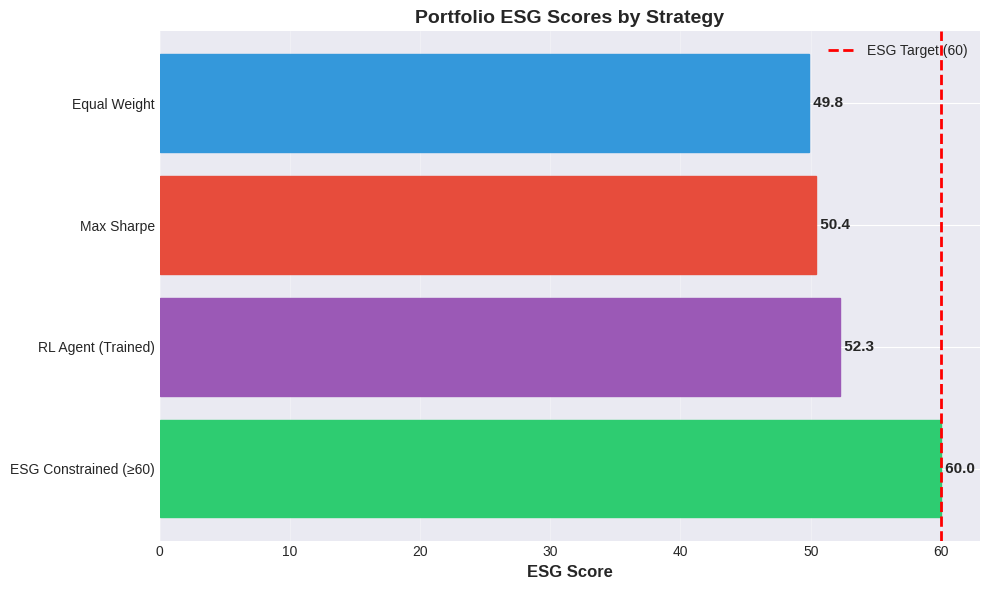

In [11]:
print("🌱 ESG CONSISTENCY ANALYSIS\n")

# ESG scores for each strategy
esg_analysis = pd.DataFrame([
    {
        'Strategy': name,
        'Portfolio ESG Score': results['esg_score'],
        'Meets ESG ≥60 Threshold': 'Yes' if results['esg_score'] >= 60 else 'No'
    }
    for name, results in backtest_results.items()
]).sort_values('Portfolio ESG Score', ascending=False)

print(esg_analysis.to_string(index=False))

# Visualize ESG scores
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bars = ax.barh(esg_analysis['Strategy'], esg_analysis['Portfolio ESG Score'])

for i, bar in enumerate(bars):
    strategy = esg_analysis.iloc[i]['Strategy']
    bar.set_color(colors[strategy])

ax.axvline(x=60, color='red', linestyle='--', linewidth=2, label='ESG Target (60)')
ax.set_xlabel('ESG Score', fontweight='bold', fontsize=12)
ax.set_title('Portfolio ESG Scores by Strategy', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(esg_analysis['Portfolio ESG Score']):
    ax.text(v, i, f' {v:.1f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 11. Statistical Significance Testing

In [12]:
from scipy import stats

print("📊 STATISTICAL SIGNIFICANCE TESTING\n")
print("Testing if RL Agent significantly outperforms other strategies...\n")

# Get RL returns
rl_returns = np.array(backtest_results['RL Agent (Trained)']['returns'])

# Compare RL against each strategy
for strategy_name, results in backtest_results.items():
    if strategy_name == 'RL Agent (Trained)':
        continue

    strategy_returns = np.array(results['returns'])

    # Paired t-test
    t_stat, p_value = stats.ttest_rel(rl_returns, strategy_returns)

    print(f"RL Agent vs {strategy_name}:")
    print(f"   t-statistic: {t_stat:.4f}")
    print(f"   p-value: {p_value:.4f}")

    if p_value < 0.05:
        if t_stat > 0:
            print(f"   ✅ RL Agent significantly OUTPERFORMS (p < 0.05)")
        else:
            print(f"   ⚠️ RL Agent significantly UNDERPERFORMS (p < 0.05)")
    else:
        print(f"   ➖ No significant difference (p >= 0.05)")
    print()

📊 STATISTICAL SIGNIFICANCE TESTING

Testing if RL Agent significantly outperforms other strategies...

RL Agent vs Equal Weight:
   t-statistic: 1.5573
   p-value: 0.1198
   ➖ No significant difference (p >= 0.05)

RL Agent vs Max Sharpe:
   t-statistic: 1.9602
   p-value: 0.0503
   ➖ No significant difference (p >= 0.05)

RL Agent vs ESG Constrained (≥60):
   t-statistic: 0.5272
   p-value: 0.5982
   ➖ No significant difference (p >= 0.05)



---
## 12. Save Backtesting Results

In [13]:
print("💾 Saving backtesting results...\n")

# Save comparison table
comparison_df.to_csv(f'{data_path}backtest_comparison.csv', index=False)
print(f"✅ Saved: {data_path}backtest_comparison.csv")

# Save out-of-sample results
oos_comparison.to_csv(f'{data_path}oos_test_results.csv', index=False)
print(f"✅ Saved: {data_path}oos_test_results.csv")

# Save stress test results
stress_comparison.to_csv(f'{data_path}stress_test_results.csv', index=False)
print(f"✅ Saved: {data_path}stress_test_results.csv")

# Save ESG analysis
esg_analysis.to_csv(f'{data_path}esg_consistency_analysis.csv', index=False)
print(f"✅ Saved: {data_path}esg_consistency_analysis.csv")

# Save portfolio values time series
portfolio_values_df = pd.DataFrame({
    'Date': returns_matrix.index,
    **{name: results['values'][1:] for name, results in backtest_results.items()}
})
portfolio_values_df.to_csv(f'{data_path}portfolio_values_timeseries.csv', index=False)
print(f"✅ Saved: {data_path}portfolio_values_timeseries.csv")

print("\n📁 All backtesting results saved!")

💾 Saving backtesting results...

✅ Saved: /content/drive/MyDrive/ESG_Portfolio_Data/backtest_comparison.csv
✅ Saved: /content/drive/MyDrive/ESG_Portfolio_Data/oos_test_results.csv
✅ Saved: /content/drive/MyDrive/ESG_Portfolio_Data/stress_test_results.csv
✅ Saved: /content/drive/MyDrive/ESG_Portfolio_Data/esg_consistency_analysis.csv
✅ Saved: /content/drive/MyDrive/ESG_Portfolio_Data/portfolio_values_timeseries.csv

📁 All backtesting results saved!


---
## 13. Final Summary & Conclusions

In [14]:
print("="*90)
print("🎯 FINAL SUMMARY & CONCLUSIONS")
print("="*90)

print("\n1️⃣ OVERALL PERFORMANCE RANKING:")
print("   Based on Sharpe Ratio (risk-adjusted returns):\n")
ranking = comparison_df.sort_values('Sharpe Ratio', ascending=False)
for idx, row in ranking.iterrows():
    print(f"   {idx+1}. {row['Strategy']:<30} Sharpe: {row['Sharpe Ratio']:.3f}")

print("\n2️⃣ ESG PERFORMANCE:")
esg_ranking = comparison_df.sort_values('ESG Score', ascending=False)
for idx, row in esg_ranking.iterrows():
    meets = '✅' if row['ESG Score'] >= 60 else '❌'
    print(f"   {meets} {row['Strategy']:<30} ESG: {row['ESG Score']:.1f}")

print("\n3️⃣ RISK MANAGEMENT:")
print("   Lowest Maximum Drawdown (best downside protection):\n")
risk_ranking = comparison_df.sort_values('Max Drawdown (%)', ascending=False)
for idx, row in risk_ranking.iterrows():
    print(f"   {idx+1}. {row['Strategy']:<30} Max DD: {row['Max Drawdown (%)']:.2f}%")

print("\n4️⃣ KEY FINDINGS:")

# Determine winner
best_sharpe_strategy = ranking.iloc[0]['Strategy']
best_esg_strategy = esg_ranking.iloc[0]['Strategy']

print(f"   • Best Risk-Adjusted Returns: {best_sharpe_strategy}")
print(f"   • Highest ESG Score: {best_esg_strategy}")
print(f"   • Most consistent: {comparison_df.loc[comparison_df['Win Rate (%)'].idxmax(), 'Strategy']}")

# RL Agent specific analysis
rl_metrics = comparison_df[comparison_df['Strategy'] == 'RL Agent (Trained)'].iloc[0]
print(f"\n5️⃣ RL AGENT PERFORMANCE:")
print(f"   • Total Return: {rl_metrics['Total Return (%)']:.2f}%")
print(f"   • Sharpe Ratio: {rl_metrics['Sharpe Ratio']:.3f}")
print(f"   • ESG Score: {rl_metrics['ESG Score']:.1f}")
print(f"   • Maintained ESG ≥60: {'Yes ✅' if rl_metrics['ESG Score'] >= 60 else 'No ❌'}")

print("\n6️⃣ TRADE-OFF ANALYSIS:")
trad_sharpe = comparison_df[comparison_df['Strategy'] == 'Max Sharpe']['Sharpe Ratio'].values[0]
esg_sharpe = comparison_df[comparison_df['Strategy'] == 'ESG Constrained (≥60)']['Sharpe Ratio'].values[0]
sharpe_cost = trad_sharpe - esg_sharpe

print(f"   • Adding ESG constraint (≥60) reduces Sharpe by: {sharpe_cost:.3f}")
print(f"   • This is the 'cost' of ESG investing")

print("\n" + "="*90)
print("✅ BACKTESTING & VALIDATION COMPLETE!")
print("   All strategies evaluated on:")
print(f"   • Full dataset: {len(returns_matrix)} trading days")
print(f"   • Out-of-sample test: Last 6 months")
print(f"   • Stress test: {len(volatile_periods)} high-volatility days")
print("="*90)

🎯 FINAL SUMMARY & CONCLUSIONS

1️⃣ OVERALL PERFORMANCE RANKING:
   Based on Sharpe Ratio (risk-adjusted returns):

   4. RL Agent (Trained)             Sharpe: 1.179
   3. ESG Constrained (≥60)          Sharpe: 0.941
   1. Equal Weight                   Sharpe: 0.535
   2. Max Sharpe                     Sharpe: 0.036

2️⃣ ESG PERFORMANCE:
   ✅ ESG Constrained (≥60)          ESG: 60.0
   ❌ RL Agent (Trained)             ESG: 52.3
   ❌ Max Sharpe                     ESG: 50.4
   ❌ Equal Weight                   ESG: 49.8

3️⃣ RISK MANAGEMENT:
   Lowest Maximum Drawdown (best downside protection):

   1. Equal Weight                   Max DD: -18.65%
   3. ESG Constrained (≥60)          Max DD: -20.43%
   4. RL Agent (Trained)             Max DD: -20.91%
   2. Max Sharpe                     Max DD: -20.93%

4️⃣ KEY FINDINGS:
   • Best Risk-Adjusted Returns: RL Agent (Trained)
   • Highest ESG Score: ESG Constrained (≥60)
   • Most consistent: RL Agent (Trained)

5️⃣ RL AGENT PERFORMANCE:
